In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchsummary import summary

num_pkts = 138
ptk_length = 256
labels = [
    "REPLAY",
    "DNP3_INFO",
    "DNP3_ENUMERATE",
    "STOP_APP",
    "NORMAL",
    "INIT_DATA",
    "COLD_RESTART",
    "WARM_RESTART",
    "DISABLE_UNSOLICITED",
]

image_folder = Path(
    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\session_images"
)
lbl_img = {}

for label in labels:
    lbl_img[label] = []
    normalized_images = list(image_folder.rglob(f"{label}_*_normalized.png"))
    normal_images = [
        f
        for f in list(image_folder.rglob(f"{label}_*.png"))
        if "normalized" not in str(f)
    ]
    lbl_img[label] = [normal_images[0], normalized_images[0]]

In [11]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
normal_path = r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\resnet18_nosampling\best_model_full.pth"
normalized_path = r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\resnet18_normalized_nosampling\best_model_full.pth"

normal_path = r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\mobilenet_v3_large_nosampling\best_model_full.pth"
normalized_path = r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\mobilenet_v3_large_normalized_nosampling\best_model_full.pth"


model_name = "resnet18" if "resnet18" in normal_path else "mobilenetv3l"
normal_model = torch.load(
    normal_path,
    weights_only=False,
    map_location=device,
)
normal_model.eval()
# Print model summary
summary(normal_model, (1, num_pkts, ptk_length))
normalized_model = torch.load(
    normalized_path,
    weights_only=False,
    map_location=device,
)
normalized_model.eval()
# Print model summary
summary(normalized_model, (1, num_pkts, ptk_length))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 69, 128]             144
       BatchNorm2d-2          [-1, 16, 69, 128]              32
         Hardswish-3          [-1, 16, 69, 128]               0
            Conv2d-4          [-1, 16, 69, 128]             144
       BatchNorm2d-5          [-1, 16, 69, 128]              32
              ReLU-6          [-1, 16, 69, 128]               0
            Conv2d-7          [-1, 16, 69, 128]             256
       BatchNorm2d-8          [-1, 16, 69, 128]              32
  InvertedResidual-9          [-1, 16, 69, 128]               0
           Conv2d-10          [-1, 64, 69, 128]           1,024
      BatchNorm2d-11          [-1, 64, 69, 128]             128
             ReLU-12          [-1, 64, 69, 128]               0
           Conv2d-13           [-1, 64, 35, 64]             576
      BatchNorm2d-14           [-1, 64,

## Image to Tensor

In [12]:
def image_to_tensor(image: np.ndarray, num_pkts: int, ptk_length: int) -> torch.Tensor:
    """
    Convert an image to a tensor suitable for model input.
    """
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    h, w = gray_img.shape
    # check num pkts
    if h < num_pkts:
        # pad with zeros
        pad_height = num_pkts - h
        gray_img = cv2.copyMakeBorder(
            gray_img, 0, pad_height, 0, 0, cv2.BORDER_CONSTANT, value=0
        )
    elif h > num_pkts:
        gray_img = gray_img[:num_pkts, :]
    # check ptk length
    if w < ptk_length:
        # pad with zeros
        pad_width = ptk_length - w
        gray_img = cv2.copyMakeBorder(
            gray_img, 0, 0, 0, pad_width, cv2.BORDER_CONSTANT, value=0
        )
    elif w > ptk_length:
        gray_img = gray_img[:, :ptk_length]
    gray_img = gray_img.astype(np.float32) / 255.0  # Normalize to [0, 1]
    tensor = torch.tensor(gray_img, dtype=torch.float32)
    tensor = tensor.unsqueeze(0)  # Add channel dimension
    tensor = tensor.unsqueeze(0)  # Add batch dimension
    return gray_img, tensor

## Inference

In [4]:
for label, images in lbl_img.items():
    normal_img = images[0]
    normalized_img = images[1]

    normal_img, normal_tensor = image_to_tensor(
        cv2.imread(str(normal_img)), num_pkts, ptk_length
    )
    normalized_image, normalized_tensor = image_to_tensor(
        cv2.imread(str(normalized_img)), num_pkts, ptk_length
    )
    normal_tensor = normal_tensor.to(device)
    normalized_tensor = normalized_tensor.to(device)

    with torch.no_grad():
        normal_output, proba = normal_model(normal_tensor)
        normalized_output, proba = normalized_model(normalized_tensor)
        normal_pred = torch.argmax(normal_output, dim=1)
        normalized_pred = torch.argmax(normalized_output, dim=1)
        print(f"Normal Image (True, Predicted): {label}, {labels[normal_pred.item()]}")
        print(
            f"Normalized Image (True, Predicted): {label}, {labels[normalized_pred.item()]}"
        )

NameError: name 'normal_model' is not defined

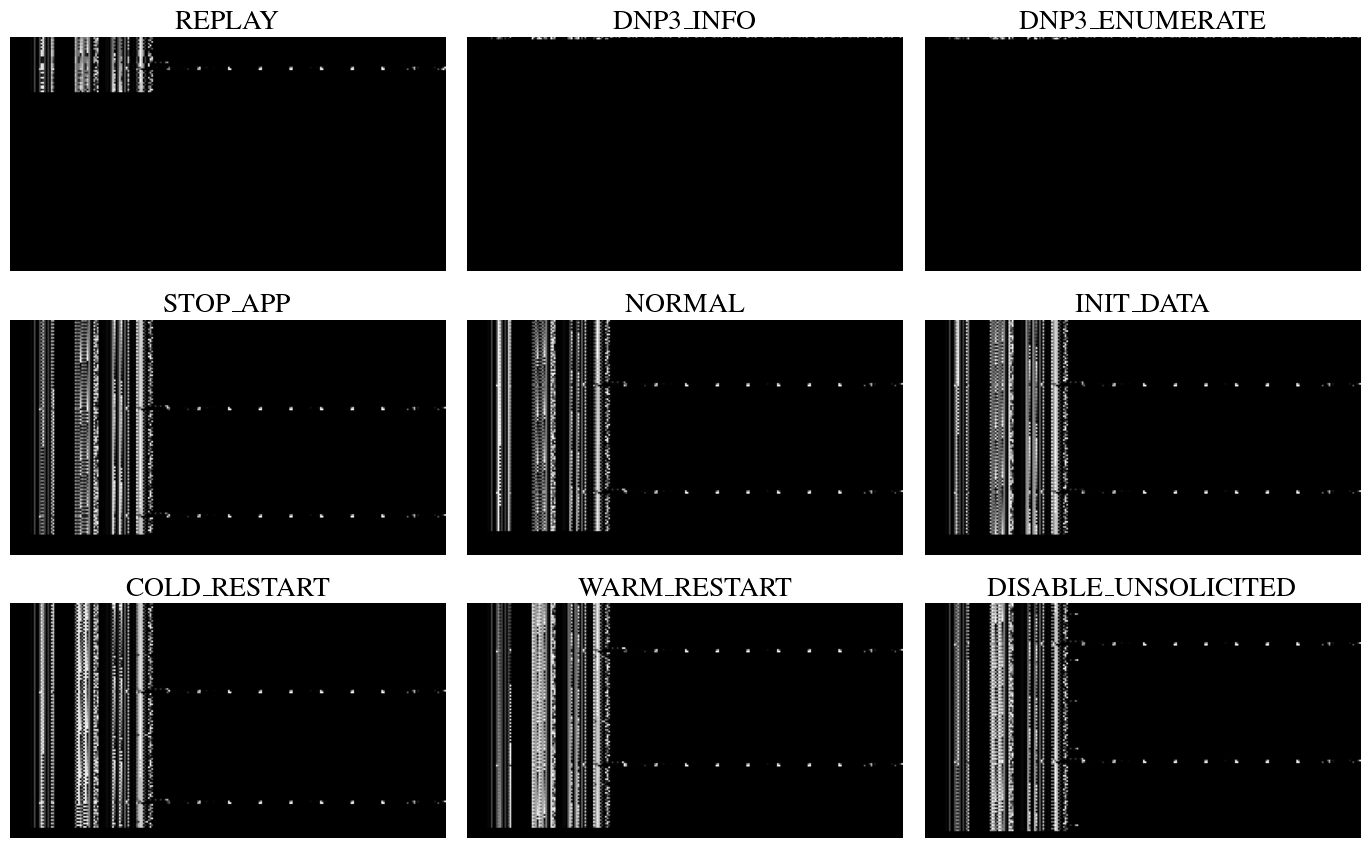

In [5]:
# just visualize the images
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font family and size
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "serif"]
mpl.rcParams["font.size"] = 12  # Adjust per Springer guidelines
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11

# Optional: PDF/LaTeX text rendering for enhanced output
mpl.rcParams["text.usetex"] = True  # Set to True only if you have a full LaTeX setup


nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 10))

for i, (label, images) in enumerate(lbl_img.items()):
    if i >= nrows * ncols:
        break
    normal_img = cv2.imread(str(images[0]))
    normal_img, _ = image_to_tensor(cv2.imread(str(images[0])), num_pkts, ptk_length)
    ax = axes[i // ncols, i % ncols]
    ax.imshow(normal_img, cmap="gray")
    ax.set_title(f"{label}", fontsize=20)
    ax.axis("off")

# Remove all spaces between subplots
plt.subplots_adjust(left=0, right=0.9, top=0.85, bottom=0, wspace=0.05, hspace=0)
# Save the figure
plt.savefig(
    r"normal_session_images.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()

### Class Weights

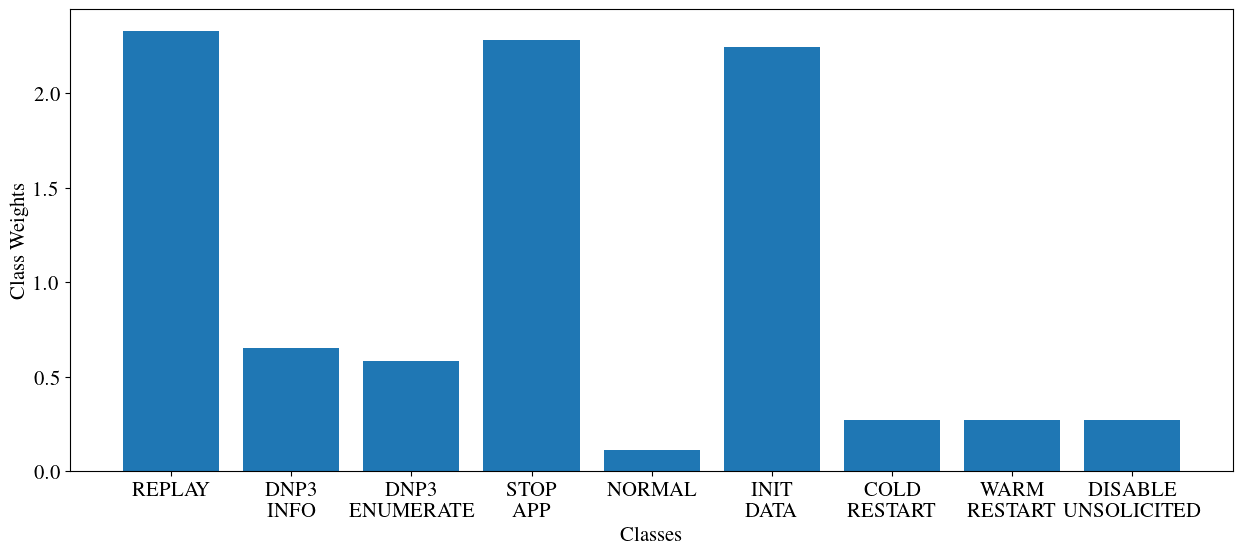

In [14]:
class_weights = {
    "REPLAY": 2.3268327713012695,
    "DNP3_INFO": 0.6492278575897217,
    "DNP3_ENUMERATE": 0.5834585428237915,
    "STOP_APP": 2.2812085151672363,
    "NORMAL": 0.10969416797161102,
    "INIT_DATA": 2.241649866104126,
    "COLD_RESTART": 0.26930931210517883,
    "WARM_RESTART": 0.26930931210517883,
    "DISABLE_UNSOLICITED": 0.26930931210517883,
}
warped_labels = ["\n".join(label.split("_")) for label in class_weights.keys()]
# plot bar chart of class weights
plt.figure(figsize=(15, 6))
plt.bar(warped_labels, class_weights.values())
plt.xlabel("Classes", fontsize=15)
plt.ylabel("Class Weights", fontsize=15)
# update the font size of the labels
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
# update the font size of the title
# plt.title("Class Weights for DNP3 Image Classification")

# add some padding around bars

# plt.tight_layout()
plt.savefig(
    r"class_weights_dnp3.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()

In [6]:
sum(class_weights.values())  # / len(class_weights)  # average class weight

8.999999657273293

## Visualize Sailency Maps

In [4]:
# pip install grad-cam

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt


class SaliencyMapVisualizer:
    def __init__(self, model):
        """
        Args:
            model (torch.nn.Module): The neural network model.
        """
        self.model = model.eval()

    def compute_saliency(self, input_tensor, target_class=None):
        """
        Computes the saliency map for a given input tensor.

        Args:
            input_tensor (torch.Tensor): Input image tensor of shape (1, C, H, W).
            target_class (int, optional): Class index for which to compute the saliency.
                                          If None, uses the predicted class.

        Returns:
            saliency_map (np.ndarray): Saliency map as a numpy array of shape (H, W).
        """
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        output, proba = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        score = output[0, target_class]

        self.model.zero_grad()
        score.backward()
        saliency = input_tensor.grad.data.abs()  # shape: (C, H, W)

        saliency_map, _ = torch.max(saliency, dim=0)
        saliency_map = saliency_map.cpu().squeeze().numpy()
        # normalize
        saliency_map = (saliency_map - saliency_map.min()) / (
            saliency_map.max() - saliency_map.min()
        )
        from scipy.ndimage import median_filter

        saliency_map = median_filter(saliency_map, size=3)

        return saliency_map

In [14]:
predictions = []
for label, images in lbl_img.items():
    print(f"Label: {label}")
    normal_img = images[0]
    normalized_img = images[1]

    normal_img, normal_tensor = image_to_tensor(
        cv2.imread(str(normal_img)), num_pkts, ptk_length
    )
    normalized_img, normalized_tensor = image_to_tensor(
        cv2.imread(str(normalized_img)), num_pkts, ptk_length
    )

    normal_tensor = normal_tensor.to(device)
    normalized_tensor = normalized_tensor.to(device)

    res = [label, normal_img, normalized_img]
    for model, input_tensor in [
        (normal_model, normal_tensor),
        (normalized_model, normalized_tensor),
    ]:
        print(f"Visualizing saliency for {label} with model {model.__class__.__name__}")
        # Create a visualizer instance
        visualizer = SaliencyMapVisualizer(model)
        # To compute the saliency map only:
        saliency_map = visualizer.compute_saliency(input_tensor)
        res.append(saliency_map)
    predictions.append(res)

Label: REPLAY
Visualizing saliency for REPLAY with model ImageClfModel
Visualizing saliency for REPLAY with model ImageClfModel
Label: DNP3_INFO
Visualizing saliency for DNP3_INFO with model ImageClfModel
Visualizing saliency for DNP3_INFO with model ImageClfModel
Label: DNP3_ENUMERATE
Visualizing saliency for DNP3_ENUMERATE with model ImageClfModel
Visualizing saliency for DNP3_ENUMERATE with model ImageClfModel
Label: STOP_APP
Visualizing saliency for STOP_APP with model ImageClfModel
Visualizing saliency for STOP_APP with model ImageClfModel
Label: NORMAL
Visualizing saliency for NORMAL with model ImageClfModel
Visualizing saliency for NORMAL with model ImageClfModel
Label: INIT_DATA
Visualizing saliency for INIT_DATA with model ImageClfModel
Visualizing saliency for INIT_DATA with model ImageClfModel
Label: COLD_RESTART
Visualizing saliency for COLD_RESTART with model ImageClfModel
Visualizing saliency for COLD_RESTART with model ImageClfModel
Label: WARM_RESTART
Visualizing salien

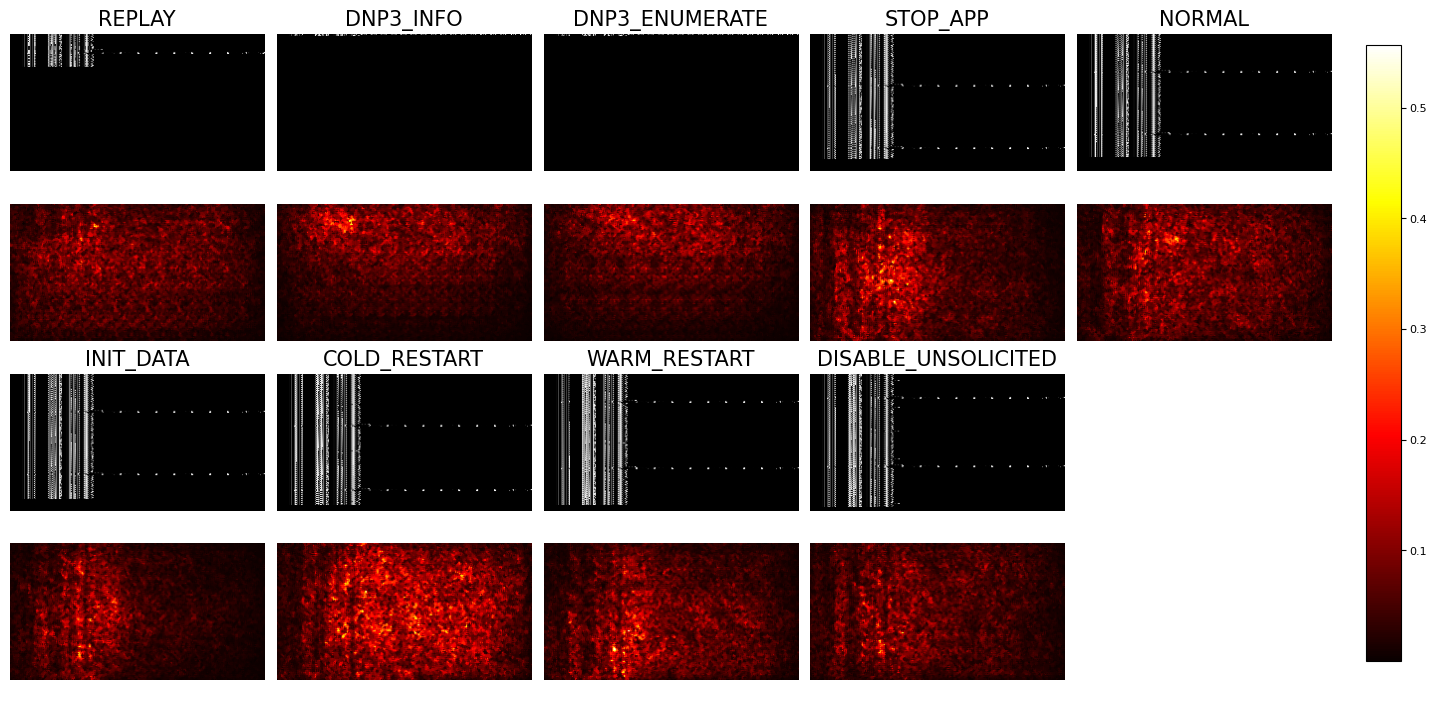

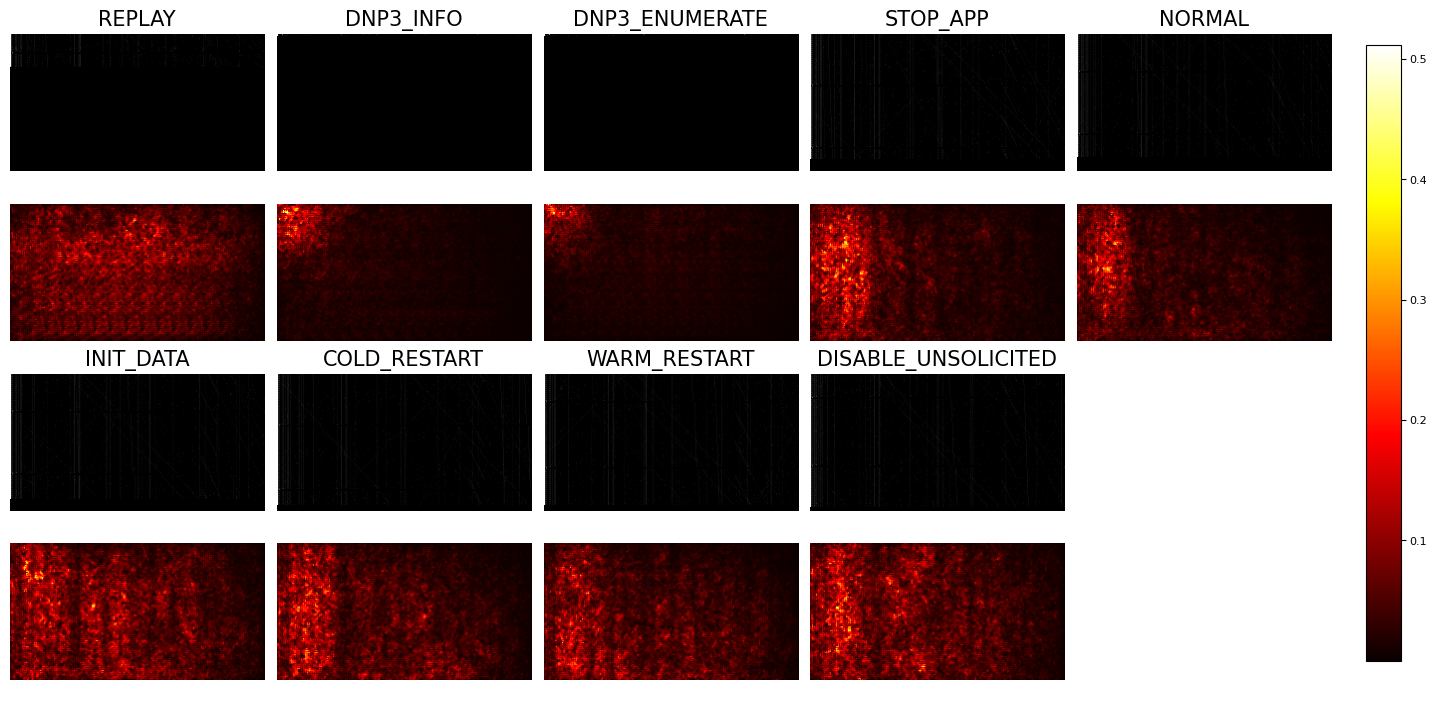

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_images_and_saliency_grid(
    data_list,
    save_as: str,
    individual_colorbars: bool = True,
    nrows: int = 3,
    ncols: int = 3,
):
    """
    Academically formatted visualization of images and saliency maps for multiple classes.

    Args:
        data_list: List of [label, image, saliency_map] for 9 classes.
                   - label: string or int (class name/ID)
                   - image: numpy array (H, W, 3) or (H, W)
                   - saliency_map: numpy array (H, W)
        save_as: Filename to save the figure.
        individual_colorbars: If True, show a colorbar for each saliency map.
                              If False, show a single colorbar for all.
    """
    num_classes = len(data_list)
    cols = ncols
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows * 2, cols, figsize=(3.5 * cols, 2.2 * rows * 2))
    vmax = max(saliency.max() for _, _, saliency in data_list)
    vmin = min(saliency.min() for _, _, saliency in data_list)

    for idx, (label, image, saliency) in enumerate(data_list):
        row = (idx // cols) * 2
        col = idx % cols

        # Image
        ax_img = axes[row, col]
        ax_img.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax_img.set_title(f"{label}", fontsize=15)
        ax_img.axis("off")

        # Saliency map (heatmap)
        ax_sal = axes[row + 1, col]
        im = ax_sal.imshow(saliency, cmap="hot", vmin=vmin, vmax=vmax)
        # ax_sal.set_title("Saliency Map", fontsize=15)
        ax_sal.axis("off")

        # Individual colorbars (if requested)
        if individual_colorbars:
            cax = inset_axes(
                ax_sal,
                width="5%",
                height="80%",
                loc="center left",
                bbox_to_anchor=(1.05, 0.0, 1, 1),
                bbox_transform=ax_sal.transAxes,
                borderpad=0,
            )
            cbar = fig.colorbar(im, cax=cax, orientation="vertical")
            cbar.ax.tick_params(labelsize=8, pad=2)

    # Hide unused subplots
    total_subplots = rows * cols
    for empty_idx in range(num_classes, total_subplots):
        row = (empty_idx // cols) * 2
        col = empty_idx % cols
        axes[row, col].axis("off")
        axes[row + 1, col].axis("off")

    if not individual_colorbars:
        # Add a single colorbar for all saliency maps
        fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.01)
        cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=8, pad=2)

    # Save the figure
    if save_as:
        # fig.savefig(save_as, bbox_inches="tight", dpi=300)
        # plt.subplots_adjust(
        #     left=0.05, right=0.88, top=0.9, bottom=0.03, wspace=0.05, hspace=0.01
        # )
        fig.savefig(save_as, dpi=300)
    plt.show()
    plt.close(fig)


plot_images_and_saliency_grid(
    [[pred[0], pred[1], pred[3]] for pred in predictions],
    save_as=f"saliency_normal_{model_name}.pdf",
    individual_colorbars=False,
    ncols=5,
)
plot_images_and_saliency_grid(
    [[pred[0], pred[2], pred[4]] for pred in predictions],
    save_as=f"saliency_normalized_{model_name}.pdf",
    individual_colorbars=False,
    ncols=5,
)

In [68]:
class ClfModel(torch.nn.Module):
    def __init__(self, model):
        super(ClfModel, self).__init__()
        self.model = model

    def forward(self, x):
        # 0 is logits 1 is proba
        return self.model(x)[1]

True: REPLAY, Predicted: REPLAY
True: REPLAY, Predicted: REPLAY
True: DNP3_INFO, Predicted: DNP3_INFO
True: DNP3_INFO, Predicted: DNP3_INFO
True: DNP3_ENUMERATE, Predicted: DNP3_ENUMERATE
True: DNP3_ENUMERATE, Predicted: DNP3_ENUMERATE
True: STOP_APP, Predicted: STOP_APP
True: STOP_APP, Predicted: STOP_APP
True: NORMAL, Predicted: NORMAL
True: NORMAL, Predicted: NORMAL
True: INIT_DATA, Predicted: INIT_DATA
True: INIT_DATA, Predicted: INIT_DATA
True: COLD_RESTART, Predicted: COLD_RESTART
True: COLD_RESTART, Predicted: COLD_RESTART
True: WARM_RESTART, Predicted: WARM_RESTART
True: WARM_RESTART, Predicted: WARM_RESTART
True: DISABLE_UNSOLICITED, Predicted: DISABLE_UNSOLICITED
True: DISABLE_UNSOLICITED, Predicted: DISABLE_UNSOLICITED


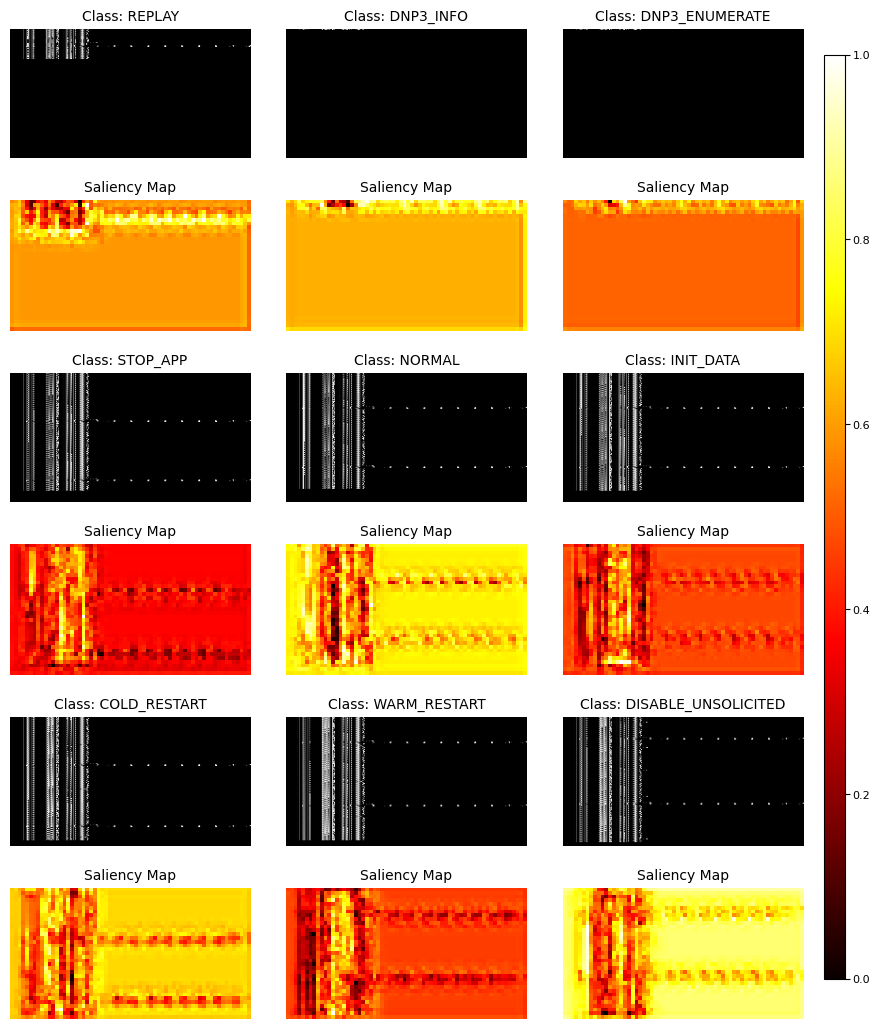

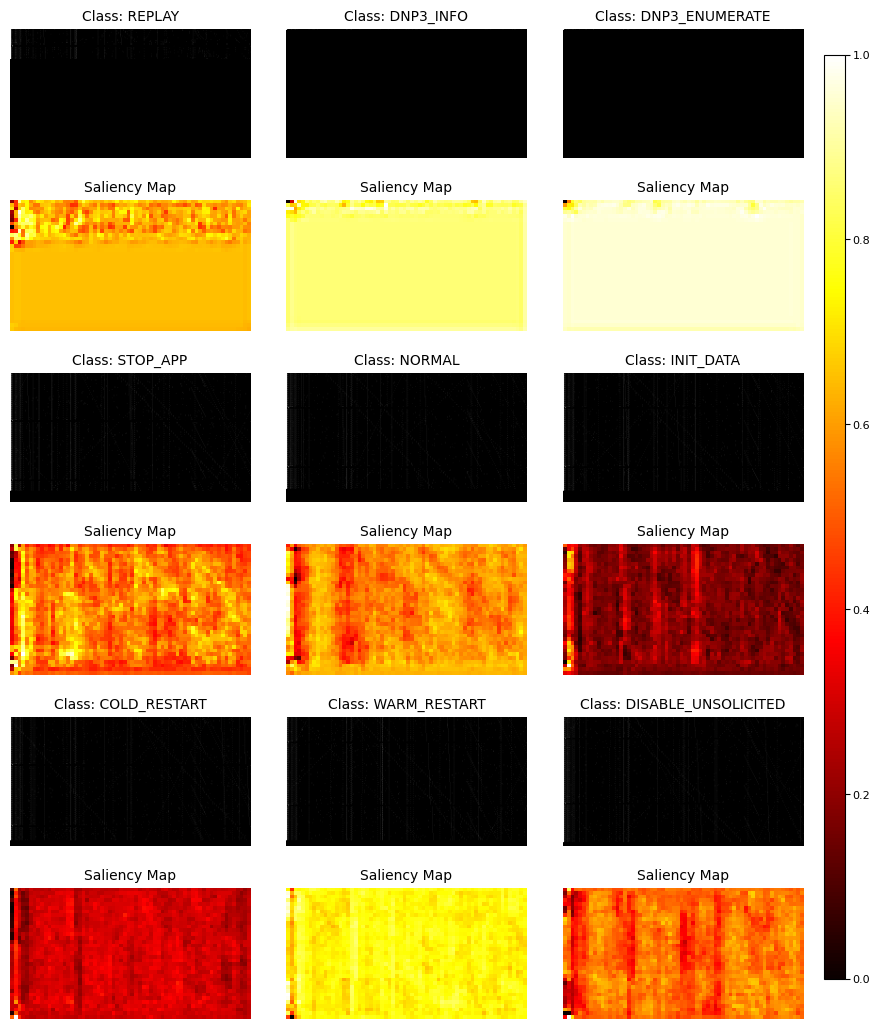

In [122]:
from captum.attr import (
    LayerGradCam,
    GuidedBackprop,
    GuidedGradCam,
    IntegratedGradients,
    Saliency,
    Deconvolution,
    InputXGradient,
    LayerGradientXActivation,
)

predictions = []
for label, images in lbl_img.items():
    normal_img = images[0]
    normalized_img = images[1]

    normal_img, normal_tensor = image_to_tensor(
        cv2.imread(str(normal_img)), num_pkts, ptk_length
    )
    normalized_img, normalized_tensor = image_to_tensor(
        cv2.imread(str(normalized_img)), num_pkts, ptk_length
    )

    normal_tensor = normal_tensor.to(device)
    normalized_tensor = normalized_tensor.to(device)

    res = [label, normal_img, normalized_img]
    for model, input_tensor in [
        (normal_model, normal_tensor),
        (normalized_model, normalized_tensor),
    ]:
        target_layer = model.backbone.layer1[-1]
        model = ClfModel(model)
        # layer_gc = GuidedBackprop(model)
        layer_gc = LayerGradCam(model, target_layer)
        # layer_gc = GuidedGradCam(model, target_layer)
        # layer_gc = IntegratedGradients(model)
        # layer_gc = Saliency(model)
        # layer_gc = LayerGradientXActivation(model, target_layer)

        # Forward pass to get prediction
        proba = model(input_tensor)
        pred_class = proba.argmax(dim=1).item()
        print(f"True: {label}, Predicted: {labels[pred_class]}")

        # use grad in inp tensor
        input_tensor.requires_grad_()

        # attribution = layer_gc.attribute(
        #     input_tensor, target=pred_class
        # )
        attribution = layer_gc.attribute(input_tensor, target=pred_class)
        saliency_map = attribution.squeeze(0, 1).detach().cpu().numpy()

        # Normalize the saliency map
        saliency_map = (saliency_map - saliency_map.min()) / (
            saliency_map.max() - saliency_map.min()
        )

        res.append(saliency_map)
    predictions.append(res)

plot_images_and_saliency_grid(
    [[pred[0], pred[1], pred[3]] for pred in predictions],
    save_as="sailency_normal.pdf",
    individual_colorbars=False,
)
plot_images_and_saliency_grid(
    [[pred[0], pred[2], pred[4]] for pred in predictions],
    save_as="sailency_normalized.pdf",
    individual_colorbars=False,
)

## Guided BP

In [68]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
normal_model = torch.load(
    r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\resnet18_nosampling\best_model_full.pth",
    weights_only=False,
    map_location=device,
)
normal_model.eval()
normalized_model = torch.load(
    r"C:\Users\Viper\Desktop\thesis_code\results\image_classification\resnet18_normalized_nosampling\best_model_full.pth",
    weights_only=False,
    map_location=device,
)
normalized_model.eval()

# Print model summary
summary(normal_model, (1, num_pkts, ptk_length))
summary(normalized_model, (1, num_pkts, ptk_length))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 64, 69, 128]           3,136
       BatchNorm2d-2          [-1, 64, 69, 128]             128
              ReLU-3          [-1, 64, 69, 128]               0
         MaxPool2d-4           [-1, 64, 35, 64]               0
            Conv2d-5           [-1, 64, 35, 64]          36,864
       BatchNorm2d-6           [-1, 64, 35, 64]             128
              ReLU-7           [-1, 64, 35, 64]               0
            Conv2d-8           [-1, 64, 35, 64]          36,864
       BatchNorm2d-9           [-1, 64, 35, 64]             128
             ReLU-10           [-1, 64, 35, 64]               0
       BasicBlock-11           [-1, 64, 35, 64]               0
           Conv2d-12           [-1, 64, 35, 64]          36,864
      BatchNorm2d-13           [-1, 64, 35, 64]             128
             ReLU-14           [-1, 64,